In [1]:
import vtuIO
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import curve_fit, minimize, differential_evolution
import os
from pathlib import Path

# Estimate stiffness modulus from uplift

In [ ]:
os.chdir(Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out")))

import Mesh_settings

# Get some data
ey = Mesh_settings.ey
ez = Mesh_settings.ez
lz = Mesh_settings.lz
initial_GWT_depth = Mesh_settings.initial_GWT_depth
duration = Mesh_settings.duration
delta_time = Mesh_settings.delta_time
layers = Mesh_settings.layers

# Ensure it only applied to 1 layer back-estimation
if len (layers)== 1:
    z_start, z_end, v_original, w_original, rho, nu, porosity = layers[0]
else:
    print('It only applies to 1 layer model.')

if ey == 1: #2D
    dim = 2                       # Dimension
    ax = 1                        # Axis
    points = {"pt0": (0, 0)}      # Define point of interest (x,z), z has to be 0, so to obtain surface displacement

else:       #3D
    dim = 3                    
    ax = 2                           
    points = {"pt0": (0, 0, 0)}      # (x,y,z)

# Some constants
sigma_ref = 100000.0  # Example reference stress in Pascals
g = 9.81  # Gravity (m/s²)

# Compute the depth affected by the rising of groundwater
depth_upper = duration - initial_GWT_depth  
depth_lower = - initial_GWT_depth 
resolution_mesh = lz/ez
depth = np.arange (depth_upper,depth_lower, -delta_time)
depth_original = np.arange (depth_upper,depth_lower, -resolution_mesh)

# Read the pvd file
pvdfile = vtuIO.PVDIO("uplift.pvd", dim=dim, interpolation_backend="scipy")

In [ ]:
time = pvdfile.timesteps
np.set_printoptions(precision=12) # Set numerical precision of data
    
# Read the accumulated displacement data
accumulated_u = pvdfile.read_time_series("displacement", points, interpolation_method="nearest")

# Calculate the time-specific displacement of all cells
total_u_at_timestep = accumulated_u["pt0"][1:, ax]-accumulated_u["pt0"][:-1, ax]

# Calculate the displacement of each GW-uplift-experiencing cell, i.e. saturation increased from 0 to 1
def compute_pts(total_u_at_timestep):
    n = len(total_u_at_timestep)
    pts = np.zeros(n)
    for i in range(n):
        pts[i] = total_u_at_timestep[i] - 2 * np.sum(pts[:i]) # minus the displacement of all bottom fully-saturated cell (i.e. 2 x displacement of partial saturated cell)
    return pts

particular_u_at_timestep = compute_pts(total_u_at_timestep) 

# Calculate Es: mesh height^2 * unit weight of water * (1-porosity) / (2* displacement of the GW-uplift-experiencing cell)
stiffness_modulus = delta_time**2 * 9.81e3 * (1-porosity) / (2*particular_u_at_timestep) 

stiffness_modulus = stiffness_modulus[::-1]

# Read the original stiffness modulus for comparison
stiffness_modulus_original= np.loadtxt("original_stiff_field.txt")
stiffness_young_conversion = (1+nu)*(1-2*nu)/(1-nu)
stiffness_modulus_original =stiffness_modulus_original/stiffness_young_conversion # convert back to stiffness modulus 

In [4]:
stiffness_modulus

array([13053641.526355686, 13986400.81905334 , 15047045.876605825,
       16747638.919217078, 19417607.2095929  , 21867726.636254713,
       21272846.145474803, 21916355.677127987, 21058940.12510933 ,
       17811151.71005467 , 22062500.978970923, 20394504.727758043,
       19999985.13101269 , 25244020.93716956 , 28455916.365438417,
       36740524.769908465, 37616886.32932279 , 35538914.26023857 ,
       45123262.53171019 , 40607037.62579801 , 33785486.75252544 ,
       37100825.690907456, 28658048.118695248, 24837696.031893853,
       22171276.306037985, 15855683.825620046, 15544041.548636219,
       18248489.825195864, 20068658.41458022 , 34244215.60455071 ,
       49711924.89792785 , 49437671.97265857 , 40146998.062543795,
       27488224.287860557, 22077307.2882403  , 23658363.082635615,
       31914360.031965397, 35976395.72026698 , 33287349.042692356,
       46546282.045473404, 60615925.113790356, 50459997.721209586,
       35249275.483859986, 34668450.36054124 , 40433505.440147

## Some parameters

In [5]:
# Compute stress
sigma =  (1 - porosity) * -depth * g * rho  

## Stiffness equation

In [6]:
# Step 1: Fit trend equation in the form:

def power_law(sigma, v_e, w_e):
    return (v_e * sigma_ref * (sigma / sigma_ref) ** w_e)

# Method of Moments

In [7]:
# # - Method 1: curve_fit
# # Fit using curve_fit with bounds
# initial_guess = [200, 0.6]
# popt, _ = curve_fit(power_law, sigma, stiffness_modulus_original, p0=initial_guess)
# trend_values = power_law(sigma, *popt) # Compute trend values
# v_e_fit, w_e_fit = popt

# - Method 2: least squares
def error_function(params, sigma, stiffness_modulus):
    v_e, w_e = params
    E_s_pred = (v_e * 1e5 * (sigma / 1e5) ** w_e) 
    return np.sum((stiffness_modulus- E_s_pred) ** 2)  # Least squares error

initial_guess = [200, 0.6]
result = minimize(error_function, initial_guess, args=(sigma, stiffness_modulus), method='Nelder-Mead') #'Nelder-Mead'
v_e_fit, w_e_fit = result.x
trend_values = power_law(sigma, v_e_fit, w_e_fit)

# Step 2: Compute detrend values
#detrend = np.log(stiffness_modulus / trend_values)
detrend = stiffness_modulus - trend_values
#if distribution == 'lognormal':
    # detrend = np.log(detrend)


In [ ]:
def sample_autocovariance(X, j):
    """
    Computes the sample autocovariance for lag j.

    Parameters:
    X : array-like
        The input data series.
    j : int
        The lag value (0 to k-1).

    Returns:
    float
        The estimated autocovariance at lag j.
    """

    X = np.asarray(X)
    k = len(X)

    mean_X = np.mean(X)
    variance_X = np.var(X, ddof=1)  # Sample variance (dividing by k-1)
    
    if j >= k:
        raise ValueError("Lag j must be less than the length of the series k.")

    add_all=[]
    for i in range (k-j):
        product = (X[i]-mean_X)*(X[i+j]-mean_X) # Cami (2020) Scale of Fluctuation for Spatially Varying Soils: Estimation Methods and Values - equation 3
        add_all.append(product)
    
    autocov = np.sum(np.array(add_all))/(k*variance_X)  # Cami equation 3
    
    return autocov  # Normalized by variance to get autocorrelation

# sample_acf_values =[]
# for j in range(len(detrend) - 1):
#     sample_acf_values.append(sample_autocovariance(detrend, j))


In [9]:
# Step 3: Fit exponential and Gaussian autocorrelation models
def exp_acf(tau, theta):
    return np.exp(-2 * np.abs(tau) / theta)

def gauss_acf(tau, theta):
    return np.exp(-np.pi * (np.abs(tau) / theta) ** 2)

In [10]:
# Define the error function, which is calculating root square difference
def error_function(theta, tau_values, sample_rho, model):
    model_rho = model(tau_values, theta)
    return np.sum((sample_rho - model_rho) ** 2)

# def error_function(theta, tau_values, sample_rho, model): # weighter absolute difference, refernce from Julia's ACF script
#     model_rho = model(tau_values, theta)
#     error = np.sum(tau_values * (sample_rho - model_rho) * model_rho)  # Weighted error
#     return abs(error)

# Compute sample autocorrelation
j_values = np.arange(0, len(detrend))  # Lag values
tau_values = j_values*0.5
sample_rho = np.array([sample_autocovariance(detrend, j) for j in j_values])

# Choose the correlation function: exp_acf or gauss_acf
correlation_function_exp = exp_acf  # or gauss_acf
correlation_function_gauss  = gauss_acf

# Optimize theta (scale of fluctuation)
initial_guess = 3  # Initial guess for theta
result_exp = opt.minimize(error_function, initial_guess, args=(tau_values, sample_rho, correlation_function_exp), method='Nelder-Mead') 
result_gauss = opt.minimize(error_function, initial_guess, args=(tau_values, sample_rho, correlation_function_gauss), method='Nelder-Mead')

# Extract optimized theta value
optimal_theta_exp = result_exp.x[0]
optimal_theta_gauss = result_gauss.x[0]

print(f"Optimized scale of fluctuation (exponetial): {optimal_theta_exp}")
print(f"Optimized scale of fluctuation (gaussian): {optimal_theta_gauss}")

Optimized scale of fluctuation (exponetial): 1.2101806640624957
Optimized scale of fluctuation (gaussian): 1.295874023437496


In [11]:
depth_original.shape

(80,)

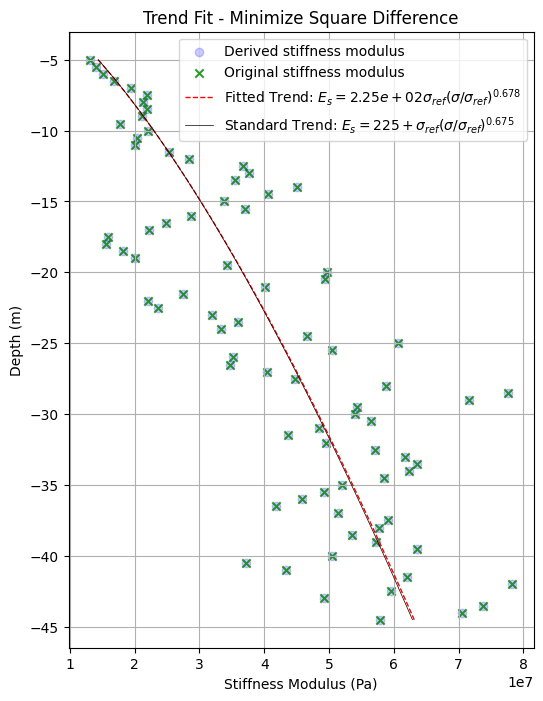

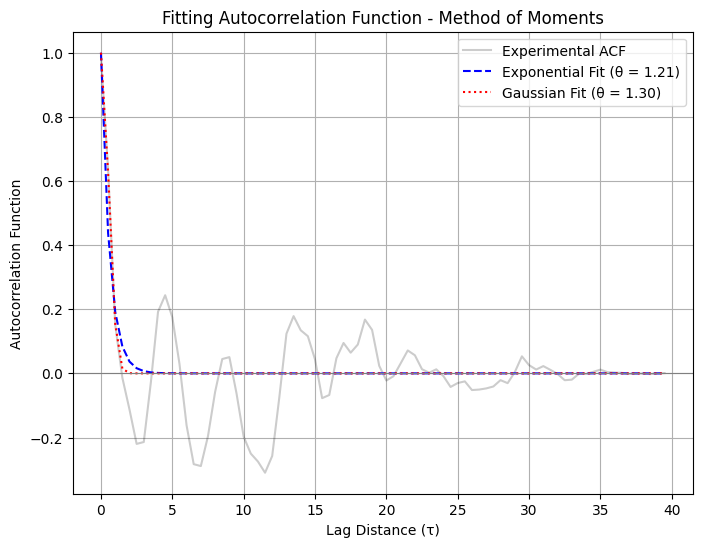

In [12]:
# === 1st Plot: Depth vs. Stiffness Modulus ===
plt.figure(figsize=(6, 8))

# Plot of derived stiffness modulus
plt.scatter(stiffness_modulus, depth, label="Derived stiffness modulus", color="blue", alpha=0.2, marker ='o')#linewidth=2, marker ='.'

# Plot of original stiffness modulus
plt.scatter(stiffness_modulus_original, depth_original, label="Original stiffness modulus", color="green", alpha=0.8, marker ='x')#linewidth=2

# Fitted trend line from optimization
plt.plot(trend_values, depth, 
         label=f"Fitted Trend: $E_s = {v_e_fit:.2e} \\sigma_{{ref}} (\\sigma/\\sigma_{{ref}})^{{{w_e_fit:.3f}}}$", 
         color="red", linewidth=1, linestyle="--")

# Standard trend line (given equation)
sigma_ref = 1e5  # Reference stress (if not defined already)
standard_trend = 225 * sigma_ref * (sigma / sigma_ref) ** 0.675 
plt.plot(standard_trend, depth, 
         label=r"Standard Trend: $E_s = 225 + \sigma_{ref} (\sigma / \sigma_{ref})^{0.675}$", 
         color="black", linewidth=0.5, linestyle="-")

# Formatting
plt.xlabel("Stiffness Modulus (Pa)")
plt.ylabel("Depth (m)")
plt.legend()
plt.title("Trend Fit - Minimize Square Difference")
plt.grid()

# Show the plot
plt.show()


# === 2nd Plot: Autocorrelation Function (ACF) vs. Tau ===
plt.figure(figsize=(8, 6))
#plt.scatter(tau_values, sample_rho, label="Experimental ACF", color="black", marker=".")
plt.plot(tau_values, sample_rho, label="Experimental ACF", color="black", alpha=0.2)
plt.plot(tau_values, exp_acf(tau_values, optimal_theta_exp), label=f"Exponential Fit (θ = {optimal_theta_exp:.2f})", color="blue", linestyle="--")
plt.plot(tau_values, gauss_acf(tau_values, optimal_theta_gauss), label=f"Gaussian Fit (θ = {optimal_theta_gauss:.2f})", color="red", linestyle=":")

plt.xlabel("Lag Distance (τ)")
plt.ylabel("Autocorrelation Function")
plt.axhline(0, color="gray", linewidth=0.8)  # Reference line at y=0
plt.legend()
plt.title("Fitting Autocorrelation Function - Method of Moments")
plt.grid()
plt.show()


In [13]:
# plt.figure(figsize=(4, 8))
# plt.scatter(stiffness_modulus, depth, label="Derived stiffness modulus", color="darkblue", alpha=0.2, marker ='o')#linewidth=2, marker ='.'
# plt.scatter(stiffness_modulus_original, depth_original, label="Original stiffness modulus", color="green", alpha=0.8, marker ='x')#linewidth=2
# plt.legend()
# plt.xlabel("Stiffness Modulus (Pa)")
# plt.ylabel("Depth (m)")

# Maximum Likelihood estimation

In [14]:
# Define log-likelihood function for LOGNORMAL distribution with covariance
def lognormal_loglikelihood(params, data, sigma, acf_func, lags):
    v_e, w_e, theta = params
    trend = power_law(sigma, v_e, w_e)
    #data = np.log(data)  # Log-transform the data
    residuals = data - trend #np.log(data / trend) # residuals = ln_Y - np.log(trend) # residuals in log-space

    k = len(data)
    covariance_matrix = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            covariance_matrix[i, j] = acf_func(np.abs(lags[i] - lags[j]), theta)

    covariance_matrix += np.eye(k) * 1e-4  # Numerical stability

    # Compute log-likelihood
    det_cov = np.linalg.det(covariance_matrix)
    inv_cov = np.linalg.inv(covariance_matrix)
    log_like = -0.5 * (k * np.log(2 * np.pi) + np.log(det_cov) + residuals.T @ inv_cov @ residuals )

    return -log_like.item()  # Negative for minimization


# Estimate scale of fluctuation using MLE
lags = np.arange(len(stiffness_modulus))
bounds = [(1e1, 1e4), (0.5, 0.8), (1e-1, 10)]  # Bounds for v_e, w_e, and theta

# differential evolution (check Liu and Leung (2018) Characterising three-dimensional anisotropic spatial correlation of soil properties through in situ test results)

# Gaussian ACF
result_gaussian = differential_evolution(lognormal_loglikelihood, bounds,
                                        args=(stiffness_modulus, sigma, gauss_acf, lags),
                                        strategy='best1bin', maxiter=200, popsize=20, tol=0.001,
                                        mutation=(0.5, 1), recombination=0.7, seed=None,
                                        disp=False, polish=True)

v_e_fit_gaussian, w_e_fit_gaussian, theta_gaussian = result_gaussian.x

# Exponential ACF
result_exponential = differential_evolution(lognormal_loglikelihood, bounds,
                                            args=(stiffness_modulus, sigma, exp_acf, lags),
                                            strategy='best1bin', maxiter=500, popsize=20, tol=0.001,
                                            mutation=(0.5, 1), recombination=0.7, seed=None,
                                            disp=False, polish=True)  

v_e_fit_exponential, w_e_fit_exponential, theta_exponential = result_exponential.x

print(f"Theta (Gaussian - Differential Evolution): {theta_gaussian:.2f}")
print(f"Theta (Exponential - Differential Evolution): {theta_exponential:.2f}")

trend_values_gaussian = power_law(sigma, v_e_fit_gaussian, w_e_fit_gaussian)
trend_values_exponential = power_law(sigma, v_e_fit_exponential, w_e_fit_exponential)


Theta (Gaussian - Differential Evolution): 2.04
Theta (Exponential - Differential Evolution): 1.99


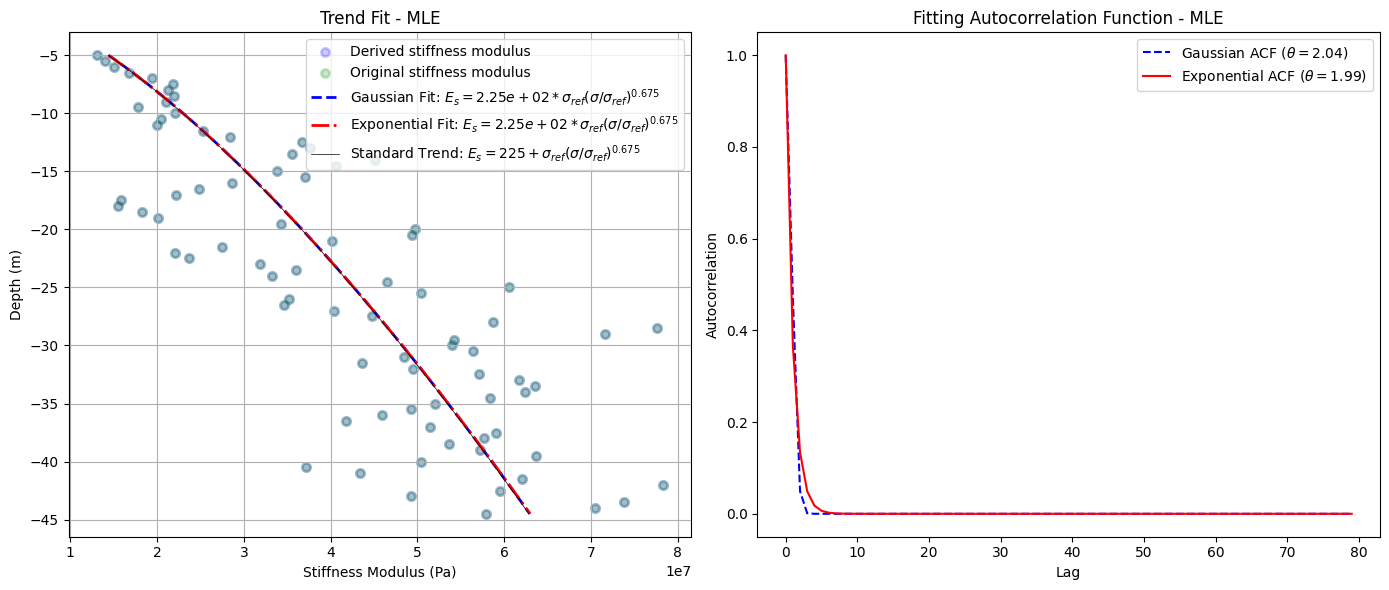

In [15]:
# Plotting 
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(stiffness_modulus, depth, label="Derived stiffness modulus", color="blue", alpha=0.2, linewidth=2)  # Data points
plt.scatter(stiffness_modulus_original, depth_original, label="Original stiffness modulus", color="green", alpha=0.2, linewidth=2)  # Data points


# Gaussian Fit
plt.plot(trend_values_gaussian, depth, label=f"Gaussian Fit: $E_s = {v_e_fit_gaussian:.2e}*\sigma_{{ref}}(\sigma/\sigma_{{ref}})^{{{w_e_fit_gaussian:.3f}}}$", 
         color='blue', linestyle='--', linewidth=2)  

# Exponential Fit
plt.plot(trend_values_exponential, depth, label=f"Exponential Fit: $E_s = {v_e_fit_exponential:.2e}*\sigma_{{ref}}(\sigma/\sigma_{{ref}})^{{{w_e_fit_exponential:.3f}}}$", 
         color='red', linestyle='-.', linewidth=2)  

# Standard Trend Line
standard_trend = 225 * 1e5 * (sigma / 1e5) ** 0.675
plt.plot(standard_trend, depth, 
         label=r"Standard Trend: $E_s = 225 + \sigma_{ref} (\sigma / \sigma_{ref})^{0.675}$", 
         color="black", linewidth=0.5, linestyle="-")


plt.ylabel("Depth (m)")
plt.xlabel("Stiffness Modulus (Pa)")
plt.legend()
plt.title("Trend Fit - MLE")
plt.grid()
plt.subplot(1, 2, 2)
lags = np.arange(len(stiffness_modulus))  # Lags for ACF plot

acf_gaussian = gauss_acf(lags, theta_gaussian)
acf_exponential = exp_acf(lags, theta_exponential)

plt.plot(lags, acf_gaussian, '--', label=rf"Gaussian ACF ($\theta={theta_gaussian:.2f}$)", color='blue')  # Line plot for Gaussian ACF
plt.plot(lags, acf_exponential, '-', label=rf"Exponential ACF ($\theta={theta_exponential:.2f}$)", color='red')  # Line plot for Exponential ACF

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Fitting Autocorrelation Function - MLE")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
os.chdir('..')

In [17]:
# need edit
# import seaborn as sns

# points = {f"pt{x}": (x, 0, 0) for x in range(0, 100, 5)}  
# displacement_nearest = pvdfile.read_time_series("displacement", points, interpolation_method="nearest")

# stiffness_modulus == np.empty(44)

# for d in displacement_nearest:
#     first_derivative_top_displacement =displacement_nearest[d][1:, 1]-displacement_nearest[d][:-1, 1]
#     second_derivative_top_displacement =first_derivative_top_displacement[1:]-first_derivative_top_displacement[:-1]
#     stiffness_modulus_new= 0.65*1000*9.81/second_derivative_top_displacement
#     stiffness_modulus = np.concatenate((stiffness_modulus, stiffness_modulus_new), axis=0)

# # Function to plot histogram with probability density function
# def plot_pdf(data, title, xlabel, ylabel, color):
#     plt.figure(figsize=(10, 6))

#     # Plot histogram with density normalization
#     sns.histplot(data, bins=10,  kde=True, color=color, stat="density", alpha=0.5)

#     # Min & Max Values
#     min_val, max_val = np.min(data), np.max(data)

#     # Annotate Min & Max Values
#     plt.axvline(min_val, color='black', linestyle='--', label=f"Min: {min_val:.2e}")
#     plt.axvline(max_val, color='black', linestyle=':', label=f"Max: {max_val:.2e}")

#     # Formatting
#     plt.title(title)
#     plt.xlabel(xlabel)
#     plt.ylabel(ylabel)
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

# # Call function to plot PDF
# plot_pdf(stiffness_modulus, "Probability Density Function of Stiffness Modulus",
#          "Stiffness Modulus", "Density", color="blue")